In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy
import json

# import scienceplots

# plt.style.use(["science", "nature"])

In [2]:
def split_team_info(df):
    """Separate team ID (letter before dash) and team name from team column."""
    df['team_id'] = df['team'].str.split('-').str[0]
    df['team_name'] = df['team'].str.split('-').str[1]
    return df

In [3]:
with open('scores.json', 'r') as f:
    data = json.load(f)

teams = data['teams']
data = pd.DataFrame(teams)
data = split_team_info(data)
data

,team,challenge1,challenge2,challenge3,team_id,team_name
0,A-GROUPA,0,1643,0,A,GROUPA
1,B-groupB,1742,215,0,B,groupB
2,C-The Comeback Team,260,0,0,C,The Comeback Team
3,D-SPIDERMAN,0,469,0,D,SPIDERMAN
4,E-Gp-E,3517,2605,0,E,Gp
5,F-Group F,1182,0,0,F,Group F
6,G-GTEAM,457,0,0,G,GTEAM
7,H-Exodia,4392,2066,0,H,Exodia
8,I-4LegsIsNotEnough,1049,0,0,I,4LegsIsNotEnough
9,W-groupW,1560,0,0,W,groupW


In [4]:
solution = {
    "challenge1": 1432,
    "challenge2": 69,
}

In [9]:
def plot_challenge(data, solutions, idx, save_svg=False):
    df = data.sort_values(f"challenge{idx}", ascending=True)
    solution_score = float(solution[f"challenge{idx}"])
    
    plt.figure(figsize=(8.5, 4))
    colors = plt.cm.tab10(numpy.linspace(0, 1, len(df)))
    bars = plt.barh(df["team"], df[f"challenge{idx}"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.axvline(solution_score, color="crimson", linestyle="--", linewidth=1.5, label=f"Solution: {solution_score}")
    plt.title(f"Challenge {idx} Team Scores")
    plt.xlabel("Score")
    plt.ylabel("Team")
    
    # Annotate each bar with its numeric score for readability.
    for bar, value in zip(bars, df[f"challenge{idx}"]):
        x_pos = value + 30 if value >= 0 else value - 220
        plt.text(x_pos, bar.get_y() + bar.get_height() / 2, f"{value:.0f}", va="center")
    
    y_top = len(df) - 10
    plt.text(solution_score + 32, y_top, f"TA solution: {solution_score:.0f}", color="crimson", va="bottom", fontsize=9)
    
    plt.tight_layout()
    if save_svg:
        plt.savefig(f"{key}_scores.svg", dpi=300, transparent=True)
    plt.show()

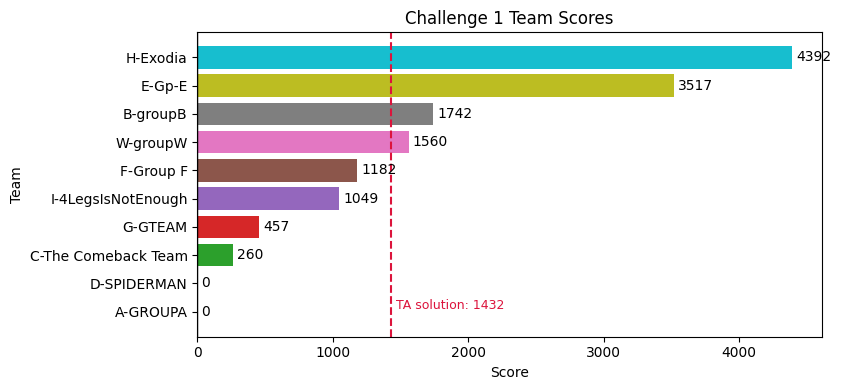

In [10]:
plot_challenge(data, solution, idx=1)

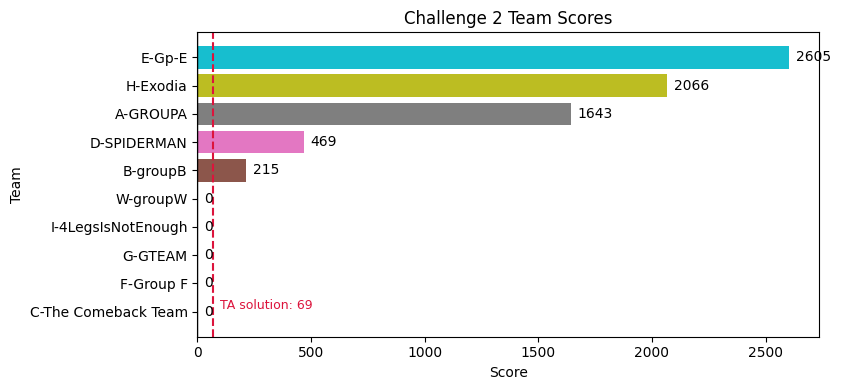

In [11]:
plot_challenge(data, solution, idx=2)